---
title: Visualizing data
format:
    pdf: default
    ipynb: default
jupyter: python3
---

[Download notebook](notebooks/08_visualizing_data.ipynb).

In this chapter, we first discuss the general principles behind choosing the right chart type, and then learn how to create plots in Python using `matplotlib`.

## Choosing the right chart {#sec-choosing-chart}

Before writing any code, it is worth thinking about what kind of chart best conveys your message. A useful framework (following Zelazny, [*Say It with Charts*](https://www.amazon.de/Say-Charts-Executivess-Communication-Executives/dp/007136997X)) proceeds in three steps:

1. **What is your message?** The chart form should not be chosen based on the data alone, but on what you want to say about it. The same table of numbers can lead to very different charts depending on the message. A good chart title states the message, not just the topic — for example, "Pasta recipes doubled on the blog since March" instead of "Recipe overview".

2. **What type of comparison does your message involve?** Every message implies one of five basic comparison types:

    * **Structure**: What share does each part have of the whole? Keywords: *share, percentage, proportion*. Example: "Italian food accounts for 40% of restaurant visits."
    * **Ranking**: How do items compare in size or order? Keywords: *larger than, smaller than, equal*. Example: "Spain is the most popular travel destination."
    * **Time series**: How does a quantity change over time? Keywords: *increase, decrease, trend, fluctuation*. Example: "Library visits have grown steadily since January."
    * **Frequency distribution**: How are values distributed across ranges? Keywords: *concentration, distribution, range*. Example: "Most hiking trails in the region are between 8 and 15 km long."
    * **Correlation**: Is there a relationship between two variables? Keywords: *relates to, follows, independent of*. Example: "There is no connection between cooking time and taste rating."

3. **Which chart form fits the comparison type?** There are five basic chart forms, and each is best suited for certain comparison types:

    * **Pie chart**: Shows parts of a whole. Best for **structure** comparisons, but use sparingly — bar charts are almost always more readable. 
    * **Box plot**: Best for comparing the **distribution** of multiple groups side by side (medians, quartiles, outliers). For a single distribution, a histogram (which is a column chart of binned data) is more informative. **Violin plots** are a refined version of box plots that additionally show the shape of the distribution.
    * **Column chart** (vertical bars): The workhorse for **time series** and **frequency distributions** when the number of data points is small (up to about six).
    * **Line chart**: Best for **time series** and **frequency distributions** with many data points. Together with column charts, these should cover about half of all charts.
    * **Bar chart** (horizontal bars): Extremely versatile. Best for **ranking** comparisons.
    * **Scatter plot**: Best for **correlation** comparisons. Also works for time series and frequency distributions with very many data points. 
    
    Beyond these basic forms, additional chart types are frequently used in data analysis, such as **heatmaps** (colored grids for correlation matrices or similar two-dimensional data).

The following matrix (adapted from Zelazny, *Say It with Charts*) summarizes which chart form to use for which comparison type. Each cell contains a small example of the recommended chart form.

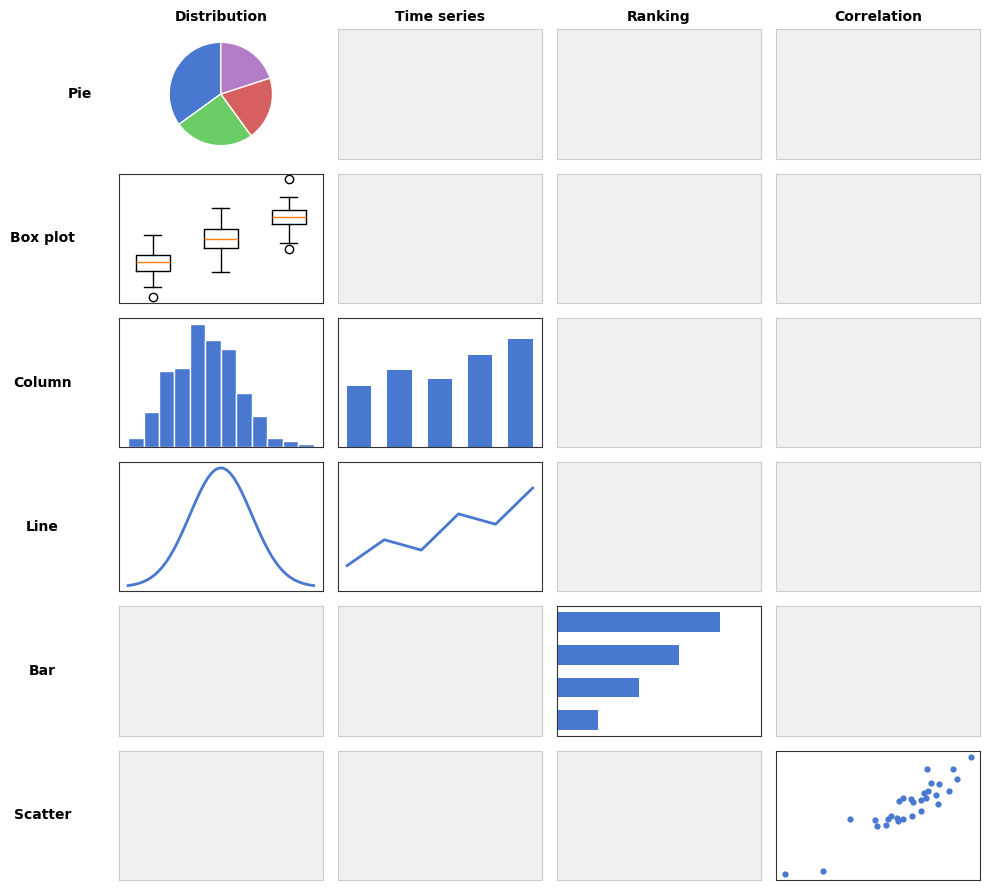

In [1]:
#| label: fig-chart-matrix
#| fig-cap: "Chart forms vs. comparison types (after Zelazny, *Say It with Charts*)"
#| echo: false
import numpy as np
import matplotlib.pyplot as plt

comparisons = ["Distribution", "Time series", "Ranking", "Correlation"]
forms = ["Pie", "Box plot", "Column", "Line", "Bar", "Scatter"]

# which cells get a plot: (row, col)
active = {
    (0, 0),                 # pie      - distribution
    (1, 0),                 # box plot - distribution
    (2, 0), (2, 1),         # column   - distribution (histogram), time series
    (3, 0), (3, 1),         # line     - distribution, time series
    (4, 2),                 # bar      - ranking
    (5, 3),                 # scatter  - correlation
}

fig, axes = plt.subplots(6, 4, figsize=(10, 9))

for i in range(6):
    for j in range(4):
        ax = axes[i, j]
        ax.set_xticks([])
        ax.set_yticks([])
        if (i, j) not in active:
            ax.set_facecolor("#f0f0f0")
            for spine in ax.spines.values():
                spine.set_color("#cccccc")
        else:
            for spine in ax.spines.values():
                spine.set_color("#333333")

# pie - distribution
ax = axes[0, 0]
ax.pie([35, 25, 20, 20], colors=["#4878cf", "#6acc65", "#d65f5f", "#b47cc7"],
       startangle=90, wedgeprops={"edgecolor": "white"})

# box plot - distribution
rng_bp = np.random.default_rng(7)
ax = axes[1, 0]
bp_data = [rng_bp.normal(loc=m, size=40) for m in [0, 1, 2.5]]
ax.boxplot(bp_data, widths=0.5)
ax.set_xticks([])

# column - distribution (histogram)
ax = axes[2, 0]
rng_hist = np.random.default_rng(42)
hist_data = rng_hist.normal(size=200)
ax.hist(hist_data, bins=12, color="#4878cf", edgecolor="white")
ax.set_yticks([])

# column - time series
ax = axes[2, 1]
ax.bar([0, 1, 2, 3, 4], [20, 25, 22, 30, 35], color="#4878cf", width=0.6)
ax.set_ylim(0, 42)

# line - time series
ax = axes[3, 1]
ax.plot([0, 1, 2, 3, 4, 5], [10, 15, 13, 20, 18, 25], color="#4878cf", linewidth=2)
ax.set_ylim(5, 30)

# line - distribution
ax = axes[3, 0]
rng = np.random.default_rng(0)
x = np.linspace(-3, 3, 50)
ax.plot(x, np.exp(-x**2 / 2), color="#4878cf", linewidth=2)

# bar - ranking
ax = axes[4, 2]
ax.barh([0, 1, 2, 3], [40, 30, 20, 10], color="#4878cf", height=0.6)
ax.set_xlim(0, 50)
ax.invert_yaxis()

# scatter - correlation
ax = axes[5, 3]
rng = np.random.default_rng(1)
xs = rng.normal(size=30)
ys = 0.8 * xs + 0.3 * rng.normal(size=30)
ax.scatter(xs, ys, s=12, color="#4878cf")

# column headers
for j, label in enumerate(comparisons):
    axes[0, j].set_title(label, fontsize=10, fontweight="bold")

# row labels
for i, label in enumerate(forms):
    axes[i, 0].set_ylabel(label, fontsize=10, fontweight="bold", rotation=0,
                           labelpad=55, va="center")

plt.tight_layout()
plt.show()

## Plotting with `matplotlib` {#sec-matplotlib}

The standard plotting library in Python is `matplotlib`. Its `pyplot` module provides a MATLAB-like interface. Here, `plt` refers to `matplotlib.pyplot`.

* `plt.figure(figsize=(w, h))`: create a new figure with given size in inches.
* `plt.xlabel("name")`, `plt.ylabel("name")`, `plt.title("name")`: add axis labels and title.
* `plt.xticks(positions, labels)`, `plt.yticks(positions, labels)`: set tick positions and labels on the x/y axis.
* `plt.legend()`: show legend. Options include `loc` for positioning (e.g., `"upper left"`), `fontsize`, and `title` for the legend title.
* `plt.show()`: display the figure.
* `plt.axvline(x)` / `plt.axhline(y)`: draw a vertical / horizontal line across the plot.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# We will generate some random data here, so we need a random number generator.
rng = np.random.default_rng(0)

## Line plots (`plot`) {#sec-line-plot}

A line plot connects data points with straight line segments. It is the standard chart for **time series** and continuous functions.

* `plt.plot(x, y, fmt, label=..., linestyle=...)`: line plot. The optional `fmt` is a shorthand format string combining color, marker, and line style, e.g. `"r*"` (red stars), `"b--"` (blue dashed), `"go-"` (green circles with solid line). Colors: `"r"` red, `"b"` blue, `"g"` green, `"k"` black. Markers: `"o"` circle, `"*"` star, `"s"` square, `"^"` triangle. The `linestyle` (or `ls`) option controls the line appearance: `"-"` solid (default), `"--"` dashed, `"-."` dash-dot, `":"` dotted.

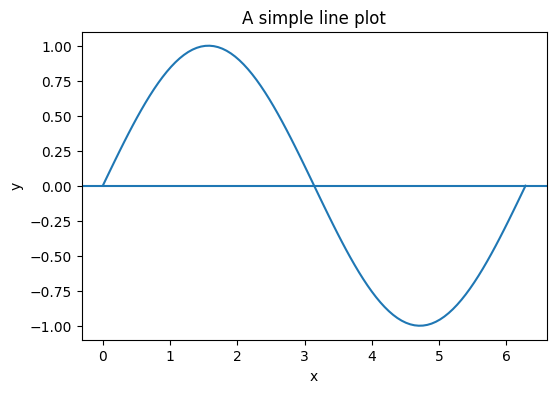

In [2]:
x = np.linspace(0, 2 * np.pi, 100)
y = np.sin(x)

plt.figure(figsize=(6, 4))
plt.plot(x, y, label="sin(x)")
plt.axhline(0)
plt.xlabel("x")
plt.ylabel("y")
plt.title("A simple line plot")
plt.show()

By default, `matplotlib` draws a rectangular box around the plot. For mathematical function plots, it is often cleaner to place the x- and y-axes at the origin and remove the box. This requires `fig, ax = plt.subplots(...)` to access the `ax.spines` object (see also @sec-subplots). Each **spine** is one of the four border lines of the plot area (`"left"`, `"right"`, `"top"`, `"bottom"`).

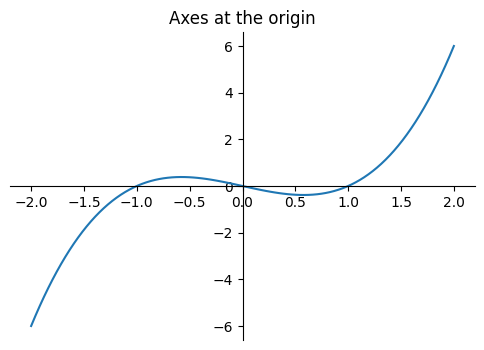

In [3]:
x = np.linspace(-2, 2, 100)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, x**3 - x, label="$x^3 - x$")

# move the left and bottom spines to x=0 and y=0
ax.spines["left"].set_position(("data", 0))
ax.spines["bottom"].set_position(("data", 0))

# hide the top and right spines
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.set_title("Axes at the origin")
plt.show()

## Pie charts (`pie`) {#sec-pie-chart}

A pie chart shows parts of a whole. Use sparingly — bar charts are almost always more readable.

* `plt.pie(values, labels=...)`: pie chart. Use `autopct` to display percentages.

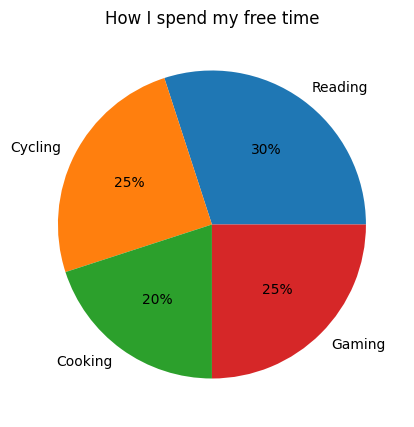

In [4]:
labels = ["Reading", "Cycling", "Cooking", "Gaming"]
values = [30, 25, 20, 25]

plt.figure(figsize=(5, 5))
plt.pie(values, labels=labels, autopct="%1.0f%%")
plt.title("How I spend my free time")
plt.show()

## Bar charts (`bar`, `barh`) {#sec-bar-chart}

Bar charts are the most versatile chart form, suitable for **structure**, **ranking**, and **comparison** tasks. Vertical bars are created with `plt.bar`, horizontal bars with `plt.barh`.

* `plt.bar(categories, values)`: vertical bar plot. Use `bottom=...` to stack bars on top of previous ones, `yerr=...` to add error bars, and `capsize=...` to set the width of the error bar caps. Use `color=...` to set the bar color, and `alpha=...` (0 to 1) to control its transparency.
* `plt.barh(categories, values)`: horizontal bar plot.

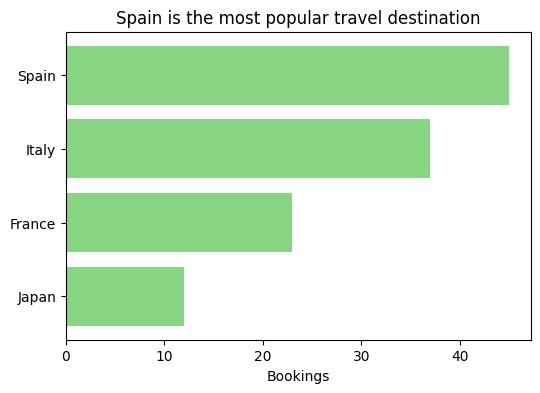

In [5]:
# horizontal bar chart (ranking)
categories = ["Japan", "France", "Italy", "Spain"]
values = [12, 23, 37, 45]

plt.figure(figsize=(6, 4))
plt.barh(categories, values, color="#6acc65", alpha=0.8)
plt.xlabel("Bookings")
plt.title("Spain is the most popular travel destination")
plt.show()

Bar charts become even more useful when comparing multiple series side by side, stacking them, showing differences, or adding error bars. To place two series next to each other, shift the bar positions by the bar width using `np.arange`.

In [6]:
# survey data: absolute number of people who named each cuisine as favourite
cuisines = ["Italian", "Japanese", "Mexican", "Indian"]
adults_abs = [70, 40, 50, 40]   # 200 adults surveyed
kids_abs = [36, 8, 24, 12]     # 80 kids surveyed

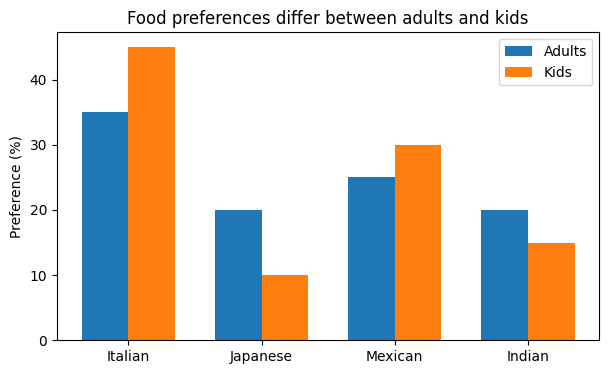

In [7]:
# grouped bar chart: compare percentages 
# (so group sizes don't distort the picture)
adults_pct = [a / sum(adults_abs) * 100 for a in adults_abs]
kids_pct = [k / sum(kids_abs) * 100 for k in kids_abs]

x = np.arange(len(cuisines))
width = 0.35

plt.figure(figsize=(7, 4))
plt.bar(x - width/2, adults_pct, width, label="Adults")
plt.bar(x + width/2, kids_pct, width, label="Kids")
plt.xticks(x, cuisines)
plt.ylabel("Preference (%)")
plt.title("Food preferences differ between adults and kids")
plt.legend()
plt.show()

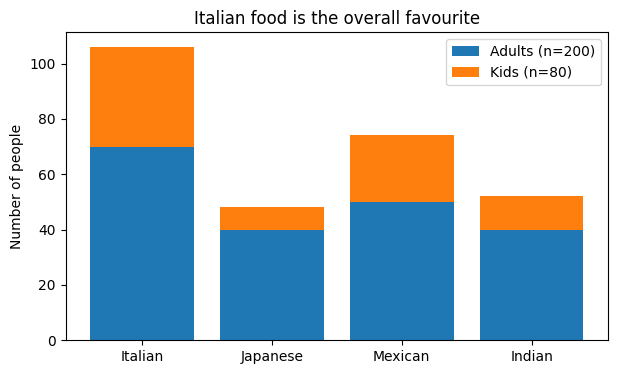

In [8]:
# stacked bar chart: absolute numbers show the total count per cuisine
plt.figure(figsize=(7, 4))
plt.bar(cuisines, adults_abs, label="Adults (n=200)")
plt.bar(cuisines, kids_abs, bottom=adults_abs, label="Kids (n=80)")
plt.ylabel("Number of people")
plt.title("Italian food is the overall favourite")
plt.legend()
plt.show()

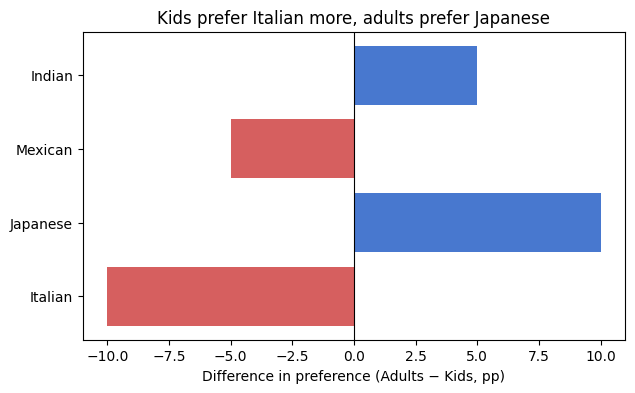

In [9]:
# difference chart: horizontal bars going left and right from a center axis
diff = [a - b for a, b in zip(adults_pct, kids_pct)]
colors = ["#4878cf" if d >= 0 else "#d65f5f" for d in diff]

plt.figure(figsize=(7, 4))
plt.barh(cuisines, diff, color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("Difference in preference (Adults − Kids, pp)")
plt.title("Kids prefer Italian more, adults prefer Japanese")
plt.show()

You can add **error bars** to a bar chart to show uncertainty (e.g., standard deviations or confidence intervals) using the `yerr` parameter.

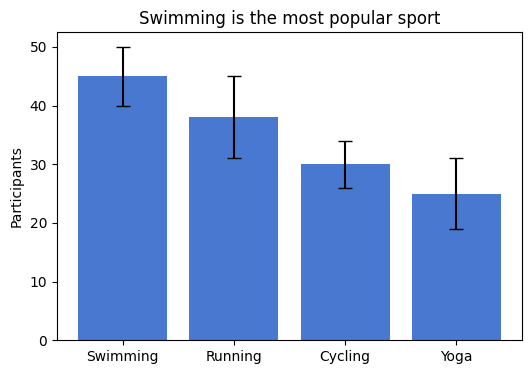

In [10]:
# bar chart with error bars
sports = ["Swimming", "Running", "Cycling", "Yoga"]
participants = [45, 38, 30, 25]
std_dev = [5, 7, 4, 6]

plt.figure(figsize=(6, 4))
plt.bar(sports, participants, yerr=std_dev, capsize=5, color="#4878cf")
plt.ylabel("Participants")
plt.title("Swimming is the most popular sport")
plt.show()

## Histograms (`hist`) {#sec-histogram}

A histogram groups numeric data into bins and shows the frequency or density of each bin. It is the standard chart for **frequency distributions**.

* `plt.hist(data, bins=..., density=...)`: histogram. Use `density=True` to normalize to a probability density, `alpha=...` (0 to 1) to make the bars semi-transparent, and `rwidth=...` (0 to 1) to control the bar width relative to the bin width (default 1.0, i.e. no gaps).

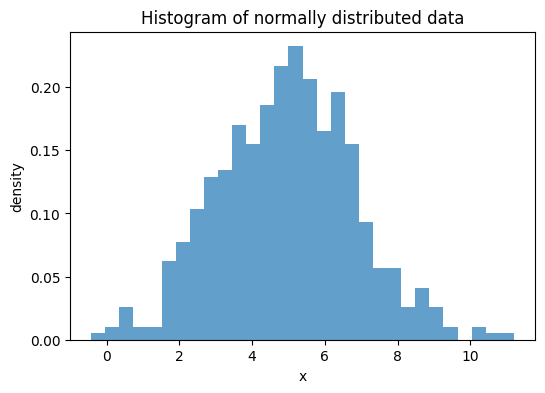

In [11]:
data = rng.normal(loc=5, scale=2, size=500)

plt.figure(figsize=(6, 4))
plt.hist(data, bins=30, density=True, alpha=0.7)
plt.xlabel("x")
plt.ylabel("density")
plt.title("Histogram of normally distributed data")
plt.show()

## Box plots (`boxplot`) {#sec-box-plot}

A box plot summarizes the distribution of a dataset. The **box** spans from the first quartile (Q1, 25th percentile) to the third quartile (Q3, 75th percentile), so it contains the middle 50% of the data. The line inside the box marks the **median** (Q2, 50th percentile). The **whiskers** extend from the box to the most extreme data points that are still within 1.5 times the interquartile range (IQR = Q3 − Q1) from the box edges. Points beyond the whiskers are shown as individual dots and considered **outliers**. Box plots are especially useful for comparing distributions across groups.

* `plt.boxplot(data_list, tick_labels=...)`: box plot. Pass a list of arrays to compare multiple groups, and `tick_labels` to label them.

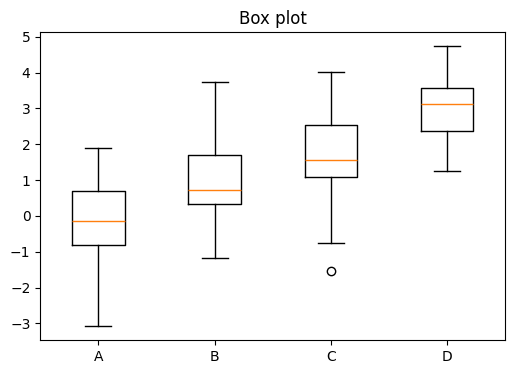

In [12]:
categories = ["A", "B", "C", "D"]
data_groups = [rng.normal(loc=m, size=50) for m in [0, 1, 2, 3]]

plt.figure(figsize=(6, 4))
plt.boxplot(data_groups, tick_labels=categories)
plt.title("Box plot")
plt.show()

## Subplots (`subplots`) {#sec-subplots}

Subplots allow placing multiple plots in a single figure. Each subplot is an independent `axes` object that supports the same methods as `plt` but prefixed with `ax.` or `axes[i].` (e.g., `axes[0].plot(...)`, `axes[0].set_title(...)`).

* `fig, axes = plt.subplots(nrows, ncols, figsize=...)`: create a grid of subplots. For a single subplot, use `fig, ax = plt.subplots(figsize=...)`.
* `plt.tight_layout()`: automatically adjust spacing so labels do not overlap.
* `ax.spines["side"].set_position(("data", value))`: move a spine (the border lines of the plot area) so that it crosses the axis at `value`. The `"side"` can be `"left"`, `"right"`, `"top"`, or `"bottom"`.
* `ax.spines["side"].set_visible(False)`: hide a spine entirely.

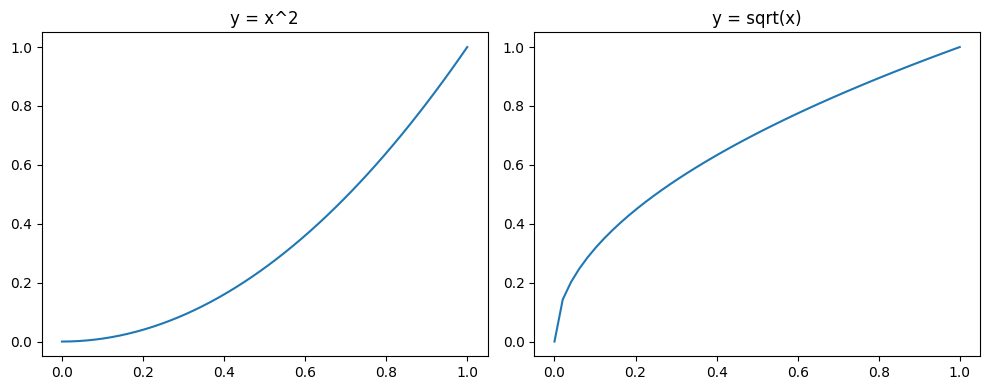

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(np.linspace(0, 1, 50), np.linspace(0, 1, 50)**2)
axes[0].set_title("y = x^2")

axes[1].plot(np.linspace(0, 1, 50), np.sqrt(np.linspace(0, 1, 50)))
axes[1].set_title("y = sqrt(x)")

plt.tight_layout()
plt.show()

## Scatter plots (`scatter`) {#sec-scatter-plot}

A scatter plot shows individual data points without connecting them. It is the primary chart for **correlation** comparisons.

* `plt.scatter(x, y, s=..., label=...)`: scatter plot (`s` is marker size).

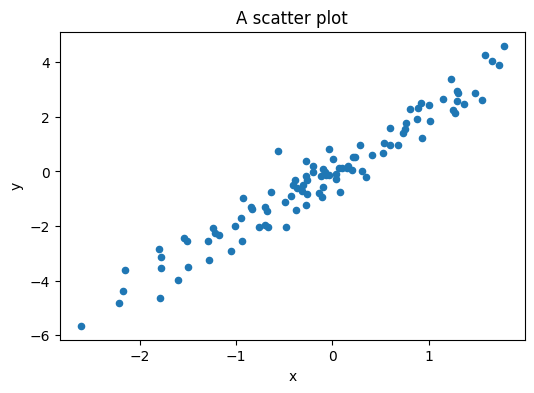

In [14]:
x = rng.normal(size=100)
y = 2 * x + 0.5 * rng.normal(size=100)

plt.figure(figsize=(6, 4))
plt.scatter(x, y, s=20)
plt.xlabel("x")
plt.ylabel("y")
plt.title("A scatter plot")
plt.show()

## Heatmaps (`imshow`) {#sec-heatmap}

A heatmap displays a matrix of values as a grid of colored cells. It is useful for visualizing correlation matrices, confusion matrices, or any two-dimensional data where patterns emerge from color. A related function is `plt.contourf`, which draws filled contour lines for data given on a 2d grid (see @sec-mle for an example).

* `plt.imshow(matrix, cmap=...)`: display a matrix as a colored grid. Use `vmin`/`vmax` to fix the color range. Common colormaps: `"viridis"` (default), `"coolwarm"` (diverging, blue to red), `"hot"`, `"gray"`, `"Blues"`, `"RdYlGn"`.
* `plt.contourf(X, Y, Z, levels=..., cmap=...)`: draw filled contour lines for values `Z` on a grid defined by `X` and `Y`. Use `levels` to control the number of contour levels.
* `plt.colorbar(label=...)`: add a color bar to the current plot, with an optional label.
* `np.corrcoef(data, rowvar=False)`: compute the correlation matrix of the columns of `data` (see @sec-descriptive for more on correlation).

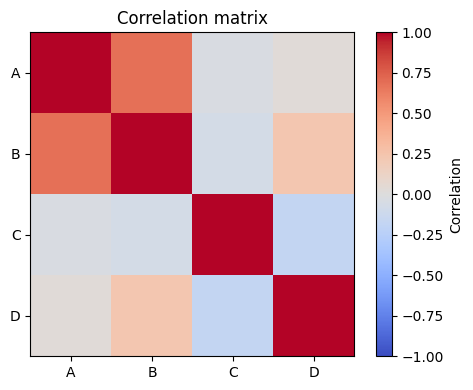

In [15]:
# heatmap of a correlation matrix
data = rng.normal(size=(100, 4))
data[:, 1] += 0.8 * data[:, 0] # introduce correlation between columns 0 and 1
labels = ["A", "B", "C", "D"]
corr = np.corrcoef(data, rowvar=False)

plt.figure(figsize=(5, 4))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.xticks(range(4), labels)
plt.yticks(range(4), labels)
plt.colorbar(label="Correlation")
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

## Exercises

All exercises in this section use the World Bank Indicators API (see @sec-loading-online). The following helper code fetches population data for a list of countries over a range of years. You may reuse and adapt it.

In [16]:
import requests

def wb_population(countries, date_range="1960:2023"):
    """Fetch total population from the World Bank API.

    countries: list of ISO3 codes, e.g. ["DEU", "FRA", "ITA"]
    date_range: year range as "start:end"
    """
    codes = ";".join(countries)
    url = f"https://api.worldbank.org/v2/country/{codes}/indicator/SP.POP.TOTL"
    response = requests.get(url, params={
        "date": date_range, "format": "json", "per_page": 5000
    })
    data = response.json()[1]
    df = pd.DataFrame([{
        "country": e["country"]["value"],
        "iso3": e["countryiso3code"],
        "year": int(e["date"]),
        "population": e["value"]
    } for e in data if e["value"] is not None])
    return df.sort_values(["iso3", "year"])

**Exercise 1**
Use `wb_population` to fetch the world population from 1960 to 2023 (ISO3 code `"WLD"`). Plot the result as a **line chart** with the year on the x-axis and population on the y-axis. Add a title that states the trend you observe.

In [ ]:
# Exercise 1

**Exercise 2**
Fetch the 2023 population for these countries: Germany (`DEU`), France (`FRA`), Italy (`ITA`), Spain (`ESP`), Poland (`POL`). Display the result as a **horizontal bar chart**, sorted by population. Which country is the most populous?

In [ ]:
# Exercise 2

**Exercise 3**
Fetch population data from 1960 to 2023 for Germany, France, and Italy. Plot all three as **line charts in the same figure** with a legend. Convert the year column to a datetime using `pd.to_datetime(df["year"], format="%Y")` and use it as the x-axis.

In [ ]:
# Exercise 3

**Exercise 4**
A survey asked 80 students about their favourite season. The results: Spring 18, Summer 30, Autumn 20, Winter 12. Display the results as a **pie chart** with percentages. Then create a second version as a **horizontal bar chart**. Which chart is easier to read?

In [ ]:
# Exercise 4

**Exercise 5**
Generate four groups of random data: `rng.normal(loc=m, scale=s, size=50)` with `(m, s)` = (5, 1), (6, 2), (5.5, 0.5), (7, 1.5). Display them as a **box plot**. Which group has the largest spread? Are there outliers?

In [ ]:
# Exercise 5

**Exercise 6**
Generate 500 samples from a normal distribution with mean 170 and standard deviation 10 (think: heights in cm). Plot a **histogram** with 25 bins and `density=True`. Overlay the theoretical density curve using `np.linspace` and `stats.norm.pdf` (you may import `from scipy import stats`). Experiment with `rwidth=0.9` and `alpha=0.7`.

In [ ]:
# Exercise 6

**Exercise 7**
Using the data from Exercise 3, compute the population growth per decade (1960s, 1970s, ..., 2010s) for each country. Display the result as a **grouped bar chart** with decades on the x-axis and one bar per country.

In [ ]:
# Exercise 7

**Exercise 8**
Fetch a second indicator — GDP per capita (`NY.GDP.PCAP.CD`) — for at least 20 European countries for the year 2022. Also fetch their population. Create a **scatter plot** of GDP per capita (x-axis) vs. population (y-axis). What do you observe? Hint: adapt the `wb_population` function by changing the indicator code.

In [ ]:
# Exercise 8

**Exercise 9**
Using the population data from Exercise 3, compute the **correlation matrix** of the three countries' populations (hint: use `pivot` to reshape the DataFrame so that each country is a column, then use `np.corrcoef` or `df.corr()`). Display the result as a **heatmap**. Why are the correlations so high?

In [ ]:
# Exercise 9